In [1]:
# Импорты

from pathlib import Path
from time import perf_counter
import os
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision import transforms
from tkinter import Tk
from tkinter.filedialog import askopenfilename

In [2]:
import sys
from pathlib import Path
sys.path.append(os.path.abspath(".."))

In [3]:
from src.embeddings import load_database
from src.embeddings import load_gemini_client
from src.embeddings import load_resnet_model
from src.embeddings import load_triplet_resnet_model
from src.embeddings import get_gemini_embedding
from src.embeddings import get_resnet_embedding
from src.embeddings import get_triplet_embedding
from src.infer import search
from src.infer import search_all_models

d:\DataScience\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Пути

ROOT = Path("..")

DATA_PATH = ROOT / "data"

MODELS_PATH = ROOT / "models"

GEMINI_ORIGINAL_PATH = ROOT / "embeddings" / "gemini_original"
GEMINI_512_PATH = ROOT / "embeddings" / "gemini_512"
RESNET50_PATH = ROOT / "embeddings" / "resnet50"
RESNET50_TRIPLET_PATH = ROOT / "embeddings" / "resnet50_triplet"

In [5]:
# Загружаем все базы эмбеддингов

gemini_original_db = load_database(GEMINI_ORIGINAL_PATH)
gemini_512_db = load_database(GEMINI_512_PATH)
resnet50_db = load_database(RESNET50_PATH)
resnet50_triplet_db = load_database(RESNET50_TRIPLET_PATH)

print("Все базы загружены.")

Все базы загружены.


In [6]:
client = load_gemini_client()

In [7]:
# Определяем устройство для вычислений

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [8]:
resnet50 = load_resnet_model(
    models_path=MODELS_PATH,
    device=device
)

d:\DataScience\My_Projects\anime_project(final_project)\src\embeddings.py:199: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


Classification ResNet loaded.


In [9]:
triplet_resnet = load_triplet_resnet_model(
    models_path=MODELS_PATH,
    device=device
)

d:\DataScience\My_Projects\anime_project(final_project)\src\embeddings.py:397: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


Triplet ResNet loaded.


In [10]:
# Преобразования изображений

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
# Выбор изображения

# Создаем скрытое окно Tkinter
root = Tk()
root.withdraw()
root.attributes("-topmost", True)

# Обновляем состояние окна перед открытием диалога
root.update()

# Открываем диалог выбора изображения
image_path = askopenfilename(
    title="Выберите скриншот",
    filetypes=[("Изображения", "*.jpg *.jpeg *.png *.webp")]
)

# Закрываем окно Tkinter
root.destroy()

print(image_path)

C:/Users/maxim/OneDrive/Изображения/Screenshots/Снимок экрана 2026-07-23 133212.png


In [12]:
embedding = get_gemini_embedding(
    image_path=image_path,
    client=client,
    mode="original",
)

print(type(embedding))

<class 'numpy.ndarray'>


In [13]:
(
    gemini_original_results,
    gemini_original_time,
    gemini_512_results,
    gemini_512_time,
    resnet50_results,
    resnet50_time,
    triplet_results,
    triplet_time,
) = search_all_models(
    image_path=image_path,
    client=client,
    resnet50=resnet50,
    triplet_resnet=triplet_resnet,
    transform=transform,
    device=device,
    gemini_original_db=gemini_original_db,
    gemini_512_db=gemini_512_db,
    resnet50_db=resnet50_db,
    resnet50_triplet_db=resnet50_triplet_db,
)

In [14]:
# Результаты поиска для каждой модели

MODELS = [
    ("Gemini Original", gemini_original_results, gemini_original_time),
    ("Gemini 512", gemini_512_results, gemini_512_time),
    ("ResNet50 Classification", resnet50_results, resnet50_time),
    ("ResNet50 Triplet", triplet_results, triplet_time),
]

In [15]:
# Отображение результатов поиска

def show_results(query_path, model_name, results):
    """
    Отображает изображение-запрос и найденные похожие изображения.

    Args:
        query_path (Path | str): Путь к изображению-запросу.
        model_name (str): Название модели, выполнившей поиск.
        results (list[tuple]): Результаты поиска в формате
            (метка класса, оценка сходства, путь к изображению).
    """
    plt.figure(figsize=(16, 4))

    # Отображаем изображение-запрос
    plt.subplot(1, 6, 1)
    plt.imshow(Image.open(query_path).convert("RGB"))
    plt.title("Query")
    plt.axis("off")

    # Отображаем пять наиболее похожих изображений
    for i, (_, _, path) in enumerate(results, start=2):
        plt.subplot(1, 6, i)
        plt.imshow(Image.open(path).convert("RGB"))
        plt.axis("off")

    # Добавляем заголовок и отображаем результат
    plt.suptitle(model_name, fontsize=15)
    plt.tight_layout()
    plt.show()

In [16]:
# Вывод результатов поиска в виде таблицы

def print_table(results):
    """
    Выводит результаты поиска в виде таблицы.

    Args:
        results (list[tuple]): Результаты поиска в формате
            (метка класса, оценка сходства, путь к изображению).
    """
    # Выводим заголовок таблицы
    print(f"{'Top':<5}{'Anime':<35}{'Score'}")
    print("-" * 55)

    # Выводим найденные результаты
    for i, (label, score, _) in enumerate(results, start=1):
        print(f"{i:<5}{label:<35}{score:.4f}")

    print()

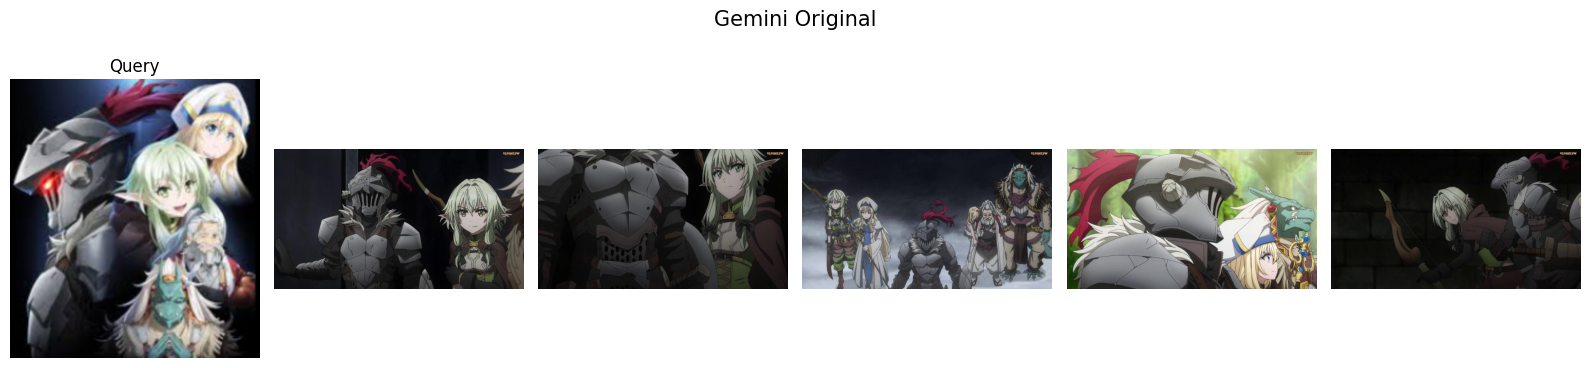

Top  Anime                              Score
-------------------------------------------------------
1    Goblin_Slayer                      0.8238
2    Goblin_Slayer                      0.8203
3    Goblin_Slayer                      0.8118
4    Goblin_Slayer                      0.8095
5    Goblin_Slayer                      0.8075



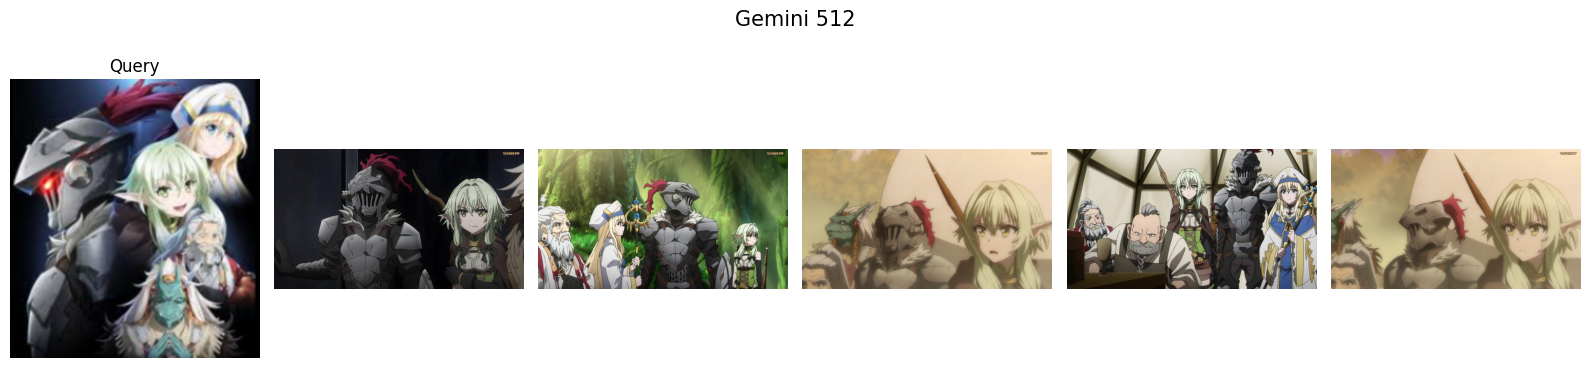

Top  Anime                              Score
-------------------------------------------------------
1    Goblin_Slayer                      0.9195
2    Goblin_Slayer                      0.9097
3    Goblin_Slayer                      0.9094
4    Goblin_Slayer                      0.9048
5    Goblin_Slayer                      0.9029



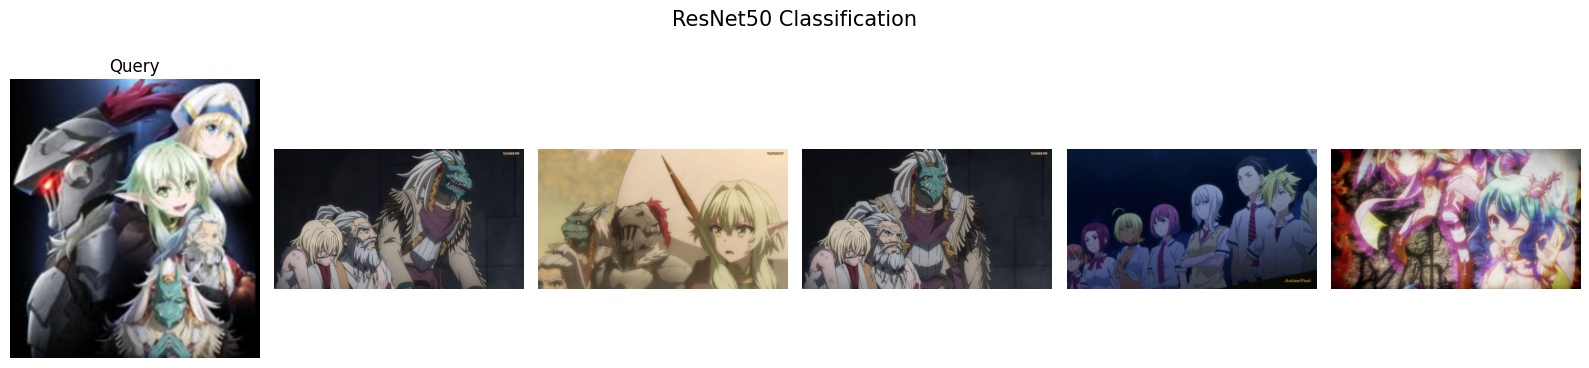

Top  Anime                              Score
-------------------------------------------------------
1    Goblin_Slayer                      0.4279
2    Goblin_Slayer                      0.4275
3    Goblin_Slayer                      0.4257
4    Shokugeki_no_Souma                 0.4209
5    No_Game_No_Life                    0.4196



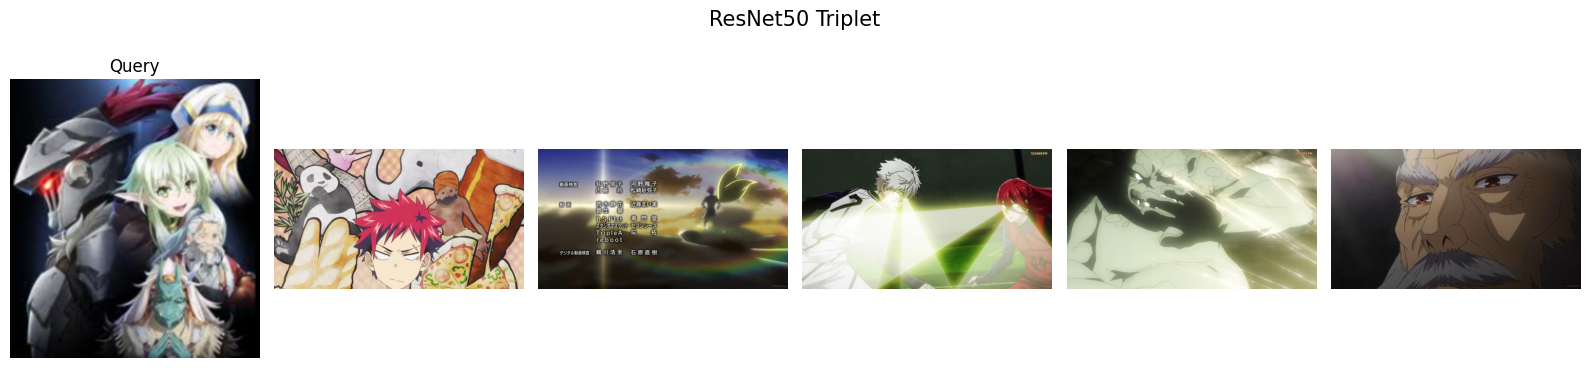

Top  Anime                              Score
-------------------------------------------------------
1    Shokugeki_no_Souma                 0.8197
2    Shokugeki_no_Souma                 0.7956
3    Blue_Lock                          0.7934
4    Goblin_Slayer                      0.7875
5    Shokugeki_no_Souma                 0.7838



In [17]:
# Отображение результатов всех моделей

for name, results, inference_time in MODELS:
    # Показываем найденные изображения
    show_results(image_path, name, results)

    # Выводим таблицу результатов
    print_table(results)

In [18]:
# Benchmark на retrieval_queries

RETRIEVAL_PATH = DATA_PATH / "retrieval_queries"


def load_retrieval_queries(root: Path):
    """
    Загружает все изображения из retrieval_queries.

    Возвращает список словарей:
        {
            "label": название аниме,
            "path": путь к изображению
        }
    """
    queries = []

    for anime_dir in sorted(root.iterdir()):

        if not anime_dir.is_dir():
            continue

        for image_path in sorted(anime_dir.iterdir()):

            if image_path.suffix.lower() not in {
                ".jpg",
                ".jpeg",
                ".png",
                ".webp",
            }:
                continue

            queries.append({
                "label": anime_dir.name,
                "path": image_path,
            })

    return queries


retrieval_queries = load_retrieval_queries(RETRIEVAL_PATH)

print(f"Queries: {len(retrieval_queries)}")

Queries: 69


In [19]:
def benchmark_model(results, true_label):
    """
    Проверяет, совпадает ли первое найденное аниме
    с правильным ответом.
    """
    predicted_label = results[0][0]

    return predicted_label == true_label

In [20]:
from tqdm.auto import tqdm

scores = {
    "Gemini Original": 0,
    "Gemini 512": 0,
    "ResNet50 Classification": 0,
    "ResNet50 Triplet": 0,
}

for sample in tqdm(retrieval_queries):

    true_label = sample["label"]
    image_path = sample["path"]

    (
        gemini_original_results,
        _,
        gemini_512_results,
        _,
        resnet50_results,
        _,
        triplet_results,
        _,
    ) = search_all_models(
        image_path=image_path,
        client=client,
        resnet50=resnet50,
        triplet_resnet=triplet_resnet,
        transform=transform,
        device=device,
        gemini_original_db=gemini_original_db,
        gemini_512_db=gemini_512_db,
        resnet50_db=resnet50_db,
        resnet50_triplet_db=resnet50_triplet_db,
    )

    if benchmark_model(gemini_original_results, true_label):
        scores["Gemini Original"] += 1

    if benchmark_model(gemini_512_results, true_label):
        scores["Gemini 512"] += 1

    if benchmark_model(resnet50_results, true_label):
        scores["ResNet50 Classification"] += 1

    if benchmark_model(triplet_results, true_label):
        scores["ResNet50 Triplet"] += 1

100%|██████████| 69/69 [10:45<00:00,  9.35s/it]


In [21]:
total = len(retrieval_queries)

print(f"{'Model':30} {'Correct':>8} {'Accuracy':>12}")
print("-" * 55)

for model, correct in scores.items():
    accuracy = correct / total * 100

    print(f"{model:30} {correct:>8} {accuracy:>11.2f}%")

Model                           Correct     Accuracy
-------------------------------------------------------
Gemini Original                      60       86.96%
Gemini 512                           60       86.96%
ResNet50 Classification              16       23.19%
ResNet50 Triplet                     26       37.68%
